# IT3212 Assignment 1 — Student Graduation Dataset Preprocessing

Preprocessing pipeline for the UCI *Predict Students' Dropout and Academic Success* dataset: exploration, cleaning, outlier handling, transformation, and train/test splitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_PATH = "../data/graduation_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(4424, 35)

## 1. Data Exploration (10)

### 1a. First rows, summary statistics, data types

In [2]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Nationality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender                                              int64
Scholarship holder                                  int64
Age at enrollm

In [4]:
df.describe(include="all")

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,7.819168,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,4.856692,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [5]:
TARGET_COL = "Target"

BINARY_COLS = [
    "Daytime/evening attendance",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
]

NOMINAL_COLS = [
    "Marital status",
    "Application mode",
    "Course",
    "Previous qualification",
    "Nationality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
]

CONTINUOUS_COLS = [
    "Application order",  # Ordered application preference, treated as numeric.
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]

assert set(BINARY_COLS) | set(NOMINAL_COLS) | set(CONTINUOUS_COLS) | {TARGET_COL} == set(df.columns)
len(BINARY_COLS), len(NOMINAL_COLS), len(CONTINUOUS_COLS)

(8, 10, 16)

### 1b. Missing values, outliers, and unique values in categorical columns

In [6]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

No missing values are reported in any column (see empty result above). We still build the missing-value
handling logic in Section 2 defensively, since the grading rubric expects it and real-world exports of this
dataset sometimes carry a handful of nulls.

In [7]:
df[TARGET_COL].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

The target classes are imbalanced (`Graduate` ≈ 50%, `Dropout` ≈ 32%, `Enrolled` ≈ 18%). This matters for
any downstream modelling (e.g. stratified splitting in Section 5) even though it isn't a preprocessing step
itself.

In [8]:
for col in BINARY_COLS + NOMINAL_COLS:
    print(f"{col:40s} n_unique={df[col].nunique():3d}  values={sorted(df[col].unique())[:10]}")

Daytime/evening attendance               n_unique=  2  values=[np.int64(0), np.int64(1)]
Displaced                                n_unique=  2  values=[np.int64(0), np.int64(1)]
Educational special needs                n_unique=  2  values=[np.int64(0), np.int64(1)]
Debtor                                   n_unique=  2  values=[np.int64(0), np.int64(1)]
Tuition fees up to date                  n_unique=  2  values=[np.int64(0), np.int64(1)]
Gender                                   n_unique=  2  values=[np.int64(0), np.int64(1)]
Scholarship holder                       n_unique=  2  values=[np.int64(0), np.int64(1)]
International                            n_unique=  2  values=[np.int64(0), np.int64(1)]
Marital status                           n_unique=  6  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Application mode                         n_unique= 18  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int

Outlier detection only makes sense on the continuous/count columns — running IQR on binary flags or nominal
codes produces meaningless "outliers" (e.g. flagging the minority class of a 0/1 column). We therefore scope
the IQR pass to `CONTINUOUS_COLS`; the actual removal/capping/transform decision is deferred to Section 3.

In [9]:
def iqr_outlier_summary(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (frame[col] < lower) | (frame[col] > upper)
        rows.append({
            "column": col,
            "q1": q1, "q3": q3, "lower_fence": lower, "upper_fence": upper,
            "n_outliers": int(mask.sum()),
            "pct_outliers": round(100 * mask.mean(), 1),
        })
    return pd.DataFrame(rows).sort_values("pct_outliers", ascending=False)

outlier_summary = iqr_outlier_summary(df, CONTINUOUS_COLS)
outlier_summary

,column,q1,q3,lower_fence,upper_fence,n_outliers,pct_outliers
11,Curricular units 2nd sem (grade),10.75,13.333333,6.875,17.208333,877,19.8
5,Curricular units 1st sem (grade),11.00,13.400000,7.400,17.000000,726,16.4
1,Curricular units 1st sem (credited),0.00,0.000000,0.000,0.000000,577,13.0
7,Curricular units 2nd sem (credited),0.00,0.000000,0.000,0.000000,530,12.0
0,Age at enrollment,19.00,25.000000,10.000,34.000000,441,10.0
2,Curricular units 1st sem (enrolled),5.00,7.000000,2.000,10.000000,424,9.6
8,Curricular units 2nd sem (enrolled),5.00,7.000000,2.000,10.000000,369,8.3
6,Curricular units 1st sem (without evaluations),0.00,0.000000,0.000,0.000000,294,6.6
12,Curricular units 2nd sem (without evaluations),0.00,0.000000,0.000,0.000000,282,6.4
4,Curricular units 1st sem (approved),3.00,6.000000,-1.500,10.500000,180,4.1


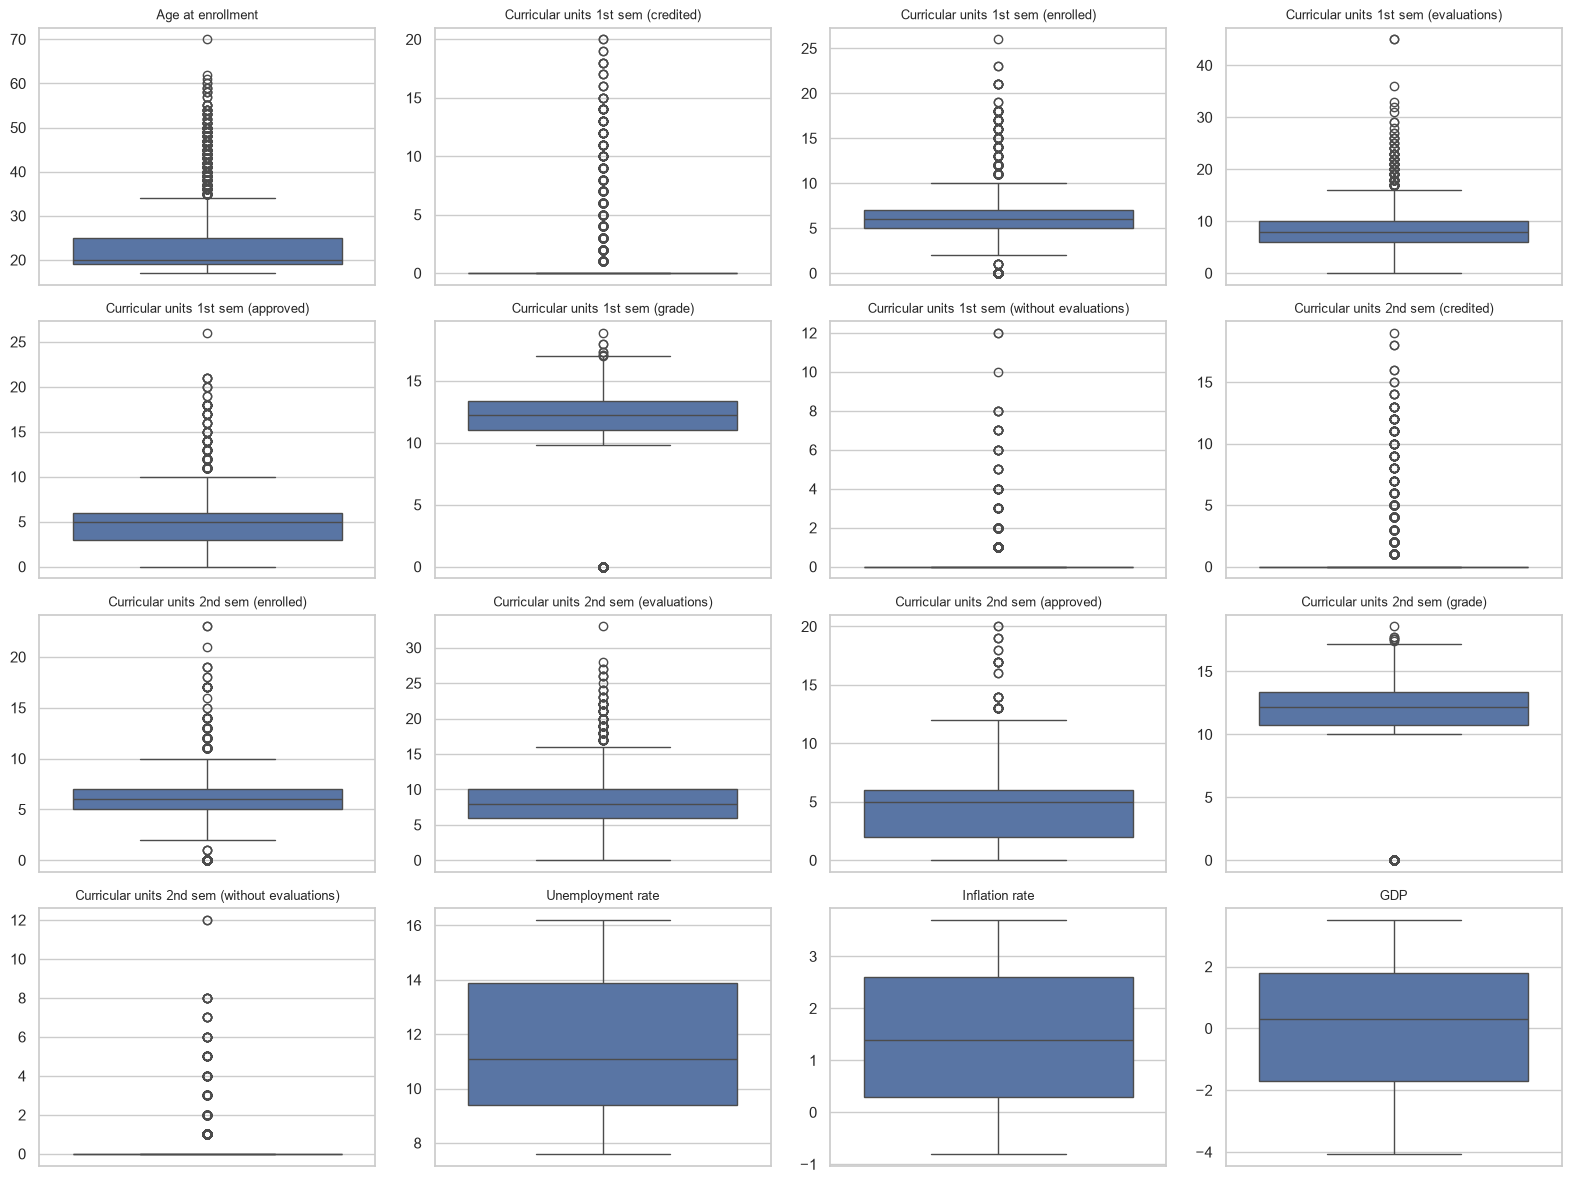

In [10]:
n_rows = (len(CONTINUOUS_COLS) + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 3 * n_rows))
for ax, col in zip(axes.ravel(), CONTINUOUS_COLS):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for ax in axes.ravel()[len(CONTINUOUS_COLS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("../figures/01_continuous_boxplots.png", dpi=150)
plt.show()

**Observations:**
- `Age at enrollment` has a long right tail (median 20, max 70) — genuine outliers from non-traditional /
  older students.
- The `Curricular units ... (grade)` columns are the most heavily flagged (~16–20%), but are also
  zero-inflated: a grade of 0 means the student had no evaluations that semester, not a true low score. This
  ambiguity needs to be resolved in Section 3 before treating those points as outliers.
- The `Curricular units ... (credited/enrolled/evaluations/approved/without evaluations)` count columns are
  right-skewed count data with many zeros, which is expected (not every student enrolls in, or gets credit
  for, the same number of units) rather than a sign of data-quality issues.
- `Unemployment rate`, `Inflation rate`, and `GDP` show 0% IQR outliers — they only take ~9–10 distinct
  values shared across cohorts admitted in the same period, so their spread is naturally tight.

## 2. Data Cleaning (20)

### 2a. Handling Missing Values

In [11]:
df_clean = df.copy()
missing_before = int(df_clean.isna().sum().sum())
rows_before = len(df_clean)

# A missing target cannot be used for supervised learning.
df_clean = df_clean.dropna(subset=[TARGET_COL])

# Continuous variables: replace missing values with the median.
for col in CONTINUOUS_COLS:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical and binary variables: replace missing values with the mode.
for col in BINARY_COLS + NOMINAL_COLS:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode().iloc[0])

cleaning_summary = pd.Series({
    "missing_before": missing_before,
    "missing_after": int(df_clean.isna().sum().sum()),
    "rows_removed_missing_target": rows_before - len(df_clean),
    "rows_after_cleaning": len(df_clean),
})
cleaning_summary

missing_before                    0
missing_after                     0
rows_removed_missing_target       0
rows_after_cleaning            4424
dtype: int64

### 2b. Chosen methods

- Missing continuous values are replaced with the column median.
- Missing categorical and binary values are replaced with the column mode.
- Rows with a missing `Target` are removed.

### 2c. Justification

The current dataset contains no missing values, so these methods do not change it. They make the pipeline robust to future missing values. The median is less affected by outliers than the mean. The mode is appropriate for categorical and binary variables because their numeric values represent categories, not quantities. A missing target is not imputed because guessing the class would introduce unreliable labels into supervised learning.

## 3. Handling Outliers (20)

### 3a. Detecting outliers with the IQR method

In [12]:
outlier_summary_clean = iqr_outlier_summary(df_clean, CONTINUOUS_COLS)
outlier_summary_clean

,column,q1,q3,lower_fence,upper_fence,n_outliers,pct_outliers
11,Curricular units 2nd sem (grade),10.75,13.333333,6.875,17.208333,877,19.8
5,Curricular units 1st sem (grade),11.00,13.400000,7.400,17.000000,726,16.4
1,Curricular units 1st sem (credited),0.00,0.000000,0.000,0.000000,577,13.0
7,Curricular units 2nd sem (credited),0.00,0.000000,0.000,0.000000,530,12.0
0,Age at enrollment,19.00,25.000000,10.000,34.000000,441,10.0
2,Curricular units 1st sem (enrolled),5.00,7.000000,2.000,10.000000,424,9.6
8,Curricular units 2nd sem (enrolled),5.00,7.000000,2.000,10.000000,369,8.3
6,Curricular units 1st sem (without evaluations),0.00,0.000000,0.000,0.000000,294,6.6
12,Curricular units 2nd sem (without evaluations),0.00,0.000000,0.000,0.000000,282,6.4
4,Curricular units 1st sem (approved),3.00,6.000000,-1.500,10.500000,180,4.1


### 3b. Treating outliers

The rows are not removed because the extreme values are plausible observations rather than clear data-entry errors. Ages above the IQR limit represent older students and are retained. Zero grades can mean that a student had no evaluations and are also retained. The non-negative curricular-unit count variables are right-skewed, so they are transformed with `log1p`. This reduces the influence of large values without deleting students or changing the order of the observations. The macroeconomic variables have no IQR outliers and are left unchanged.

In [13]:
COUNT_COLS = [
    col for col in CONTINUOUS_COLS
    if col.startswith("Curricular units") and not col.endswith("(grade)")
]

assert (df_clean[COUNT_COLS] >= 0).all().all()

skew_before = df_clean[COUNT_COLS].skew()
LOG_TRANSFORM_COLS = skew_before[skew_before > 2].index.tolist()

df_outlier_handled = df_clean.copy()
df_outlier_handled[LOG_TRANSFORM_COLS] = np.log1p(
    df_outlier_handled[LOG_TRANSFORM_COLS]
)

skewness_comparison = pd.DataFrame({
    "before_log1p": skew_before,
    "after_log1p": df_outlier_handled[COUNT_COLS].skew(),
    "transformed": [col in LOG_TRANSFORM_COLS for col in COUNT_COLS],
})
skewness_comparison

,before_log1p,after_log1p,transformed
Curricular units 1st sem (credited),4.169049,2.779233,True
Curricular units 1st sem (enrolled),1.619041,1.619041,False
Curricular units 1st sem (evaluations),0.976637,0.976637,False
Curricular units 1st sem (approved),0.766262,0.766262,False
Curricular units 1st sem (without evaluations),8.207403,4.642712,True
Curricular units 2nd sem (credited),4.634820,3.009337,True
Curricular units 2nd sem (enrolled),0.788114,0.788114,False
Curricular units 2nd sem (evaluations),0.336497,0.336497,False
Curricular units 2nd sem (approved),0.306279,0.306279,False
Curricular units 2nd sem (without evaluations),7.267701,4.695525,True


Only count columns with strong positive skewness (`skew > 2`) are log-transformed. The other count columns are retained unchanged because `log1p` moved their skewness farther from zero. A negative skewness value describes the direction of the distribution's tail; it does not mean that the transformed data contain negative values.

## 4. Data Transformation (30)

### 4a. Encoding categorical data

In [14]:
X = df_outlier_handled.drop(columns=[TARGET_COL])
y = df_outlier_handled[TARGET_COL]

# One-hot encode nominal predictors; binary predictors are already 0/1.
X_encoded = pd.get_dummies(
    X,
    columns=NOMINAL_COLS,
    dtype=int,
)

# Encode the target as one numeric class per student.
TARGET_MAPPING = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
y_encoded = y.map(TARGET_MAPPING)

assert y_encoded.notna().all()
X.shape, X_encoded.shape, y_encoded.value_counts().sort_index()

((4424, 34),
 (4424, 252),
 Target
 0    1421
 1     794
 2    2209
 Name: count, dtype: int64)

One-hot encoding is used for nominal predictors because their integer codes are category labels without a meaningful numerical order. It creates a separate 0/1 column for each category and avoids implying that one category is larger than another. Binary predictors are already represented as 0/1 and need no further encoding. The target is label-encoded because each student belongs to exactly one of the three target classes.

### 4b. Feature scaling

Standardization transforms each continuous feature using $z=(x-\mu)/\sigma$, giving the training column a mean near 0 and a standard deviation near 1. This prevents features with large numerical ranges from dominating distance- or gradient-based models and can improve numerical stability and training speed. Binary and one-hot columns remain as 0/1 because they already share a common scale. The data are split before scaling so that the scaler can be fitted only on the training data; the same fitted scaler then transforms the test data. This prevents information from the test set from leaking into preprocessing.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SCALE_COLS = CONTINUOUS_COLS.copy()
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded,
)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test_scaled[SCALE_COLS] = scaler.transform(X_test[SCALE_COLS])

scaling_check = pd.DataFrame({
    "train_mean": X_train_scaled[SCALE_COLS].mean(),
    "train_std": X_train_scaled[SCALE_COLS].std(ddof=0),
})
scaling_check.round(3)

,train_mean,train_std
Age at enrollment,0.0,1.0
Curricular units 1st sem (credited),0.0,1.0
Curricular units 1st sem (enrolled),0.0,1.0
Curricular units 1st sem (evaluations),-0.0,1.0
Curricular units 1st sem (approved),0.0,1.0
Curricular units 1st sem (grade),0.0,1.0
Curricular units 1st sem (without evaluations),-0.0,1.0
Curricular units 2nd sem (credited),0.0,1.0
Curricular units 2nd sem (enrolled),-0.0,1.0
Curricular units 2nd sem (evaluations),-0.0,1.0


#### Before and after standardization

In [19]:
scaling_comparison = pd.DataFrame({
    "mean_before": X_train[SCALE_COLS].mean(),
    "std_before": X_train[SCALE_COLS].std(ddof=0),
    "mean_after": X_train_scaled[SCALE_COLS].mean(),
    "std_after": X_train_scaled[SCALE_COLS].std(ddof=0),
})
scaling_comparison.round(3)

,mean_before,std_before,mean_after,std_after
Age at enrollment,23.250,7.604,0.0,1.0
Curricular units 1st sem (credited),0.219,0.608,0.0,1.0
Curricular units 1st sem (enrolled),6.265,2.494,0.0,1.0
Curricular units 1st sem (evaluations),8.291,4.187,-0.0,1.0
Curricular units 1st sem (approved),4.702,3.095,0.0,1.0
Curricular units 1st sem (grade),10.623,4.871,0.0,1.0
Curricular units 1st sem (without evaluations),0.070,0.277,-0.0,1.0
Curricular units 2nd sem (credited),0.185,0.538,0.0,1.0
Curricular units 2nd sem (enrolled),6.227,2.219,-0.0,1.0
Curricular units 2nd sem (evaluations),8.038,3.968,-0.0,1.0


## 5. Data Splitting (10)

### 5a. Training and test sets

As in Section 4b, the data are split into 80% training data and 20% test data using stratification.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "percentage": [
        100 * len(X_train) / len(X_encoded),
        100 * len(X_test) / len(X_encoded),
    ],
}, index=["Training set", "Test set"])

assert len(X_train) + len(X_test) == len(X_encoded)
split_summary.round(1)

,rows,percentage
Training set,3539,80.0
Test set,885,20.0


### 5b. Why the split is important

The model is fitted on the training set, while the test set is kept separate for an unbiased evaluation on unseen students. Evaluating on the same data used for training could hide overfitting because the model may memorize training patterns instead of learning patterns that generalize. A large difference between training and test performance can reveal overfitting. Stratification preserves approximately the same proportions of `Dropout`, `Enrolled`, and `Graduate` in both sets, and `random_state=42` makes the split reproducible.

## 6. Bonus Task: Principal Component Analysis (PCA) (10)

PCA combines correlated features into new, uncorrelated principal components. It uses the data standardized in Section 4b: numerical features are standardized while binary and one-hot features remain 0/1. This avoids amplifying rare categories by scaling each indicator to unit variance. The scaler and PCA are fitted only on training data.

In [26]:
from sklearn.decomposition import PCA

X_train_for_pca = X_train_scaled
X_test_for_pca = X_test_scaled

# Explore how many components are needed for several variance levels.
pca_full = PCA(svd_solver="full")
pca_full.fit(X_train_for_pca)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

PCA_VARIANCE_LEVELS = [0.80, 0.90, 0.95, 0.99]
components_required = [
    int(np.searchsorted(cumulative_variance, level) + 1)
    for level in PCA_VARIANCE_LEVELS
]

pca_comparison = pd.DataFrame({
    "variance_retained": PCA_VARIANCE_LEVELS,
    "components_required": components_required,
    "features_removed": [X_train.shape[1] - n for n in components_required],
    "reduction_pct": [
        100 * (X_train.shape[1] - n) / X_train.shape[1]
        for n in components_required
    ],
}, index=[f"{int(level * 100)}%" for level in PCA_VARIANCE_LEVELS])

# Use 95% as the selected balance between reduction and retained variance.
SELECTED_VARIANCE = 0.95
pca = PCA(n_components=SELECTED_VARIANCE, svd_solver="full")
X_train_pca = pca.fit_transform(X_train_for_pca)
X_test_pca = pca.transform(X_test_for_pca)

pca_comparison.round(3)

,variance_retained,components_required,features_removed,reduction_pct
80%,0.80,20,232,92.063
90%,0.90,38,214,84.921
95%,0.95,54,198,78.571
99%,0.99,88,164,65.079


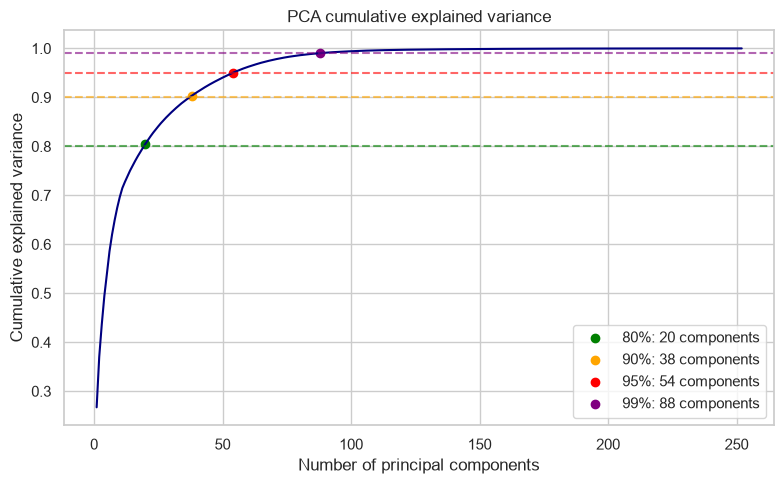

In [27]:
plt.figure(figsize=(8, 5))
component_numbers = np.arange(1, len(cumulative_variance) + 1)
plt.plot(component_numbers, cumulative_variance, color="navy")

colors = ["green", "orange", "red", "purple"]
for level, n_components, color in zip(
    PCA_VARIANCE_LEVELS, components_required, colors
):
    plt.axhline(level, color=color, linestyle="--", alpha=0.6)
    plt.scatter(
        n_components, cumulative_variance[n_components - 1],
        color=color, label=f"{int(level * 100)}%: {n_components} components"
    )

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/02_pca_explained_variance.png", dpi=150)
plt.show()

The comparison illustrates the trade-off in choosing a PCA threshold: lower thresholds use fewer components and produce a smaller dataset, but discard more variation; higher thresholds preserve more variation but provide less dimensionality reduction. A 95% threshold is selected as a compromise. PCA can remove redundancy between correlated features, reduce storage and computation, and sometimes reduce overfitting. The trade-off is that each component mixes many original features and is harder to interpret. PCA preserves variance rather than class-separating information, so improved predictive performance is not guaranteed and must be verified with a model.